<div>
    <img src="AER-logo.PNG" width="500" class="center">
</div>

# Ansys AEDT Lab Exercise: Design a dipole antenna and its matching network

## In this lab session, we will see how to use Python to create a dipole antenna and design the matching network. 

For this, we will define the parameters of the antenna, create the model of the dipole together with the boundary conditions and excitation of the problem in *Ansys HFSS*. After that, we will define the set up and analyze. We will plot the S11 parameter and radiation pattern and we will get the input impedance. Outside HFSS, we will design the matching network for this impedance and we will finally analyze in *Ansys Circuit* the designed matching network together with the antenna to prove the improvement in the antenna performace. A final exercise to understand how the length of the dipole affects the operating frequency is proposed. 

To accomplish these goals, we will follow the next steps:

1. Background: dipole antennas
2. Create a dipole in *Ansys HFSS*
3. Antenna post-processing
4. Designing the impedance matching network
5. Co-simulation in *Ansys Circuit*
6. Final exercise: Parametric analysis
7. Solution: Parametric analysis

### 1. Background: dipole antennas

- Dipole antennas are one of the most widely used types of antenna for communications.

- A dipole antenna commonly consists of two identical conductive elements such as metal wires or rods.

- The driving current from the transmitter is applied, or for receiving antennas the output signal to the receiver is taken,
between the two halves of the antenna. 

- Each side of the feedline to the transmitter or receiver is connected to one of the conductors.

- The visualization of the magnitud of the electric field in a dipole is shown in the next picture.

![SegmentLocal](dipole.gif "dipole")

### 2. Create a dipole in *Ansys HFSS*

In this section, we are going to create a $\lambda$-dipole in *Ansys HFSS*, working at the specific frequency of 1GHz

![SegmentLocal](dipole_lambda.png "dipole_lambda")

#### Frequency input

We first define the design frequency and then the start and stop frequencies for the analysis sweep

In [1]:
frequency = 1 # GHz

In [2]:
start_frequency = 0.5 # GHz

In [3]:
stop_frequency = 1.5 # GHz

In [4]:
frequency_str = str(frequency) + "GHz"

#### Parameters in "cm"

Now, we calculate the wavelength ($\lambda$) in cm

In [5]:
light_speed = 3e8 # m/s

In [6]:
light_speed_cm = light_speed * 100 # cm/s

In [7]:
wavelength_cm = light_speed_cm/(frequency*1e9)

#### Antenna parameters

To define the dipole length, radius and feeding gap, we use the following commands

In [8]:
dipole_length = 0.45 * wavelength_cm

In [9]:
feed_gap = 0.0075 * wavelength_cm

In [10]:
dipole_radius = 0.0075 * wavelength_cm

#### Open *Ansys HFSS*

In [11]:
import pyaedt
import os

In [12]:
project_name = pyaedt.generate_unique_name("Antenna_Lab")

We will use 2024.2 version and a 'Modal' solution type

In [13]:
hfss = pyaedt.Hfss(project=project_name, design="Dipole Antenna", version="2024.2", student_version=False, solution_type="Modal")

PyAEDT INFO: Python version 3.10.12 (remotes/origin/3b5d0b535dfa1177dc4fc3b6f40c990a1085eaab-dirty:3b5d0b53, Mar 25 2) [MSC v.1920 64 bit (AMD64)]
PyAEDT INFO: PyAEDT version 0.10.0.
PyAEDT INFO: Initializing new Desktop session.
PyAEDT INFO: Log on console is enabled.
PyAEDT INFO: Log on file C:\Users\cgomezmo\AppData\Local\Temp\pyaedt_cgomezmo_a7045598-5de0-47ab-a154-4749e318452b.log is enabled.
PyAEDT INFO: Log on AEDT is enabled.
PyAEDT INFO: Debug logger is disabled. PyAEDT methods will not be logged.
PyAEDT INFO: {15932: 50051}
PyAEDT INFO: Launching PyAEDT with gRPC plugin.
PyAEDT INFO: Connecting to AEDT session on gRPC port 50051
PyAEDT INFO: AEDT installation Path C:\Program Files\AnsysEM\v242\Win64
PyAEDT INFO: Project Antenna_Lab_Q4T0AX has been created.
PyAEDT INFO: Added design 'Dipole Antenna' of type HFSS.
PyAEDT INFO: Aedt Objects correctly read


And define the metric units as centimeters

In [14]:
hfss.modeler.model_units = "cm"

PyAEDT INFO: Modeler class has been initialized! Elapsed time: 0m 4sec


#### Define parameters

Now, we create the variables to define the length and radius of the dipole and the feeding gap

In [15]:
hfss["dipole_length"] = str(dipole_length) + hfss.modeler.model_units

In [16]:
hfss["feed_gap"] = str(feed_gap) + hfss.modeler.model_units

In [17]:
hfss["dipole_radius"] = str(dipole_radius) + hfss.modeler.model_units

#### Create the dipole geometry

First, we create a cylinder using the already defined parameters. At this point, we can assign 'PEC (Perfect Electric Conductor)' as material

In [18]:
arm1 = hfss.modeler.create_cylinder(orientation="Z", origin=[0, 0, "feed_gap/2"], radius=hfss["dipole_radius"], height="dipole_length/2 - feed_gap/2", name="arm1", material="pec")

PyAEDT INFO: Materials class has been initialized! Elapsed time: 0m 0sec


Then, the cylinder is duplicated to create the second arm of the dipole 

In [19]:
arm2 = arm1.duplicate_around_axis(axis="X", angle=180, clones=2, create_new_objects=True)

We create then the rectangle sheet for the port

In [20]:
port = hfss.modeler.create_rectangle(orientation="Z", origin=["-dipole_radius", 0, "-feed_gap/2"], sizes=["dipole_radius", "2*feed_gap"], name="port")

In [21]:
hfss.modeler.fit_all()

And finally we plot the geometry

In [22]:
import warnings
warnings.filterwarnings('ignore')

PyAEDT INFO: Parsing C:/Users/cgomezmo/OneDrive - ANSYS, Inc/Documents/Ansoft/Antenna_Lab_Q4T0AX.aedt.
PyAEDT INFO: File C:/Users/cgomezmo/OneDrive - ANSYS, Inc/Documents/Ansoft/Antenna_Lab_Q4T0AX.aedt correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: aedt file load time 0.06559038162231445
PyAEDT INFO: PostProcessor class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Post class has been initialized! Elapsed time: 0m 0sec


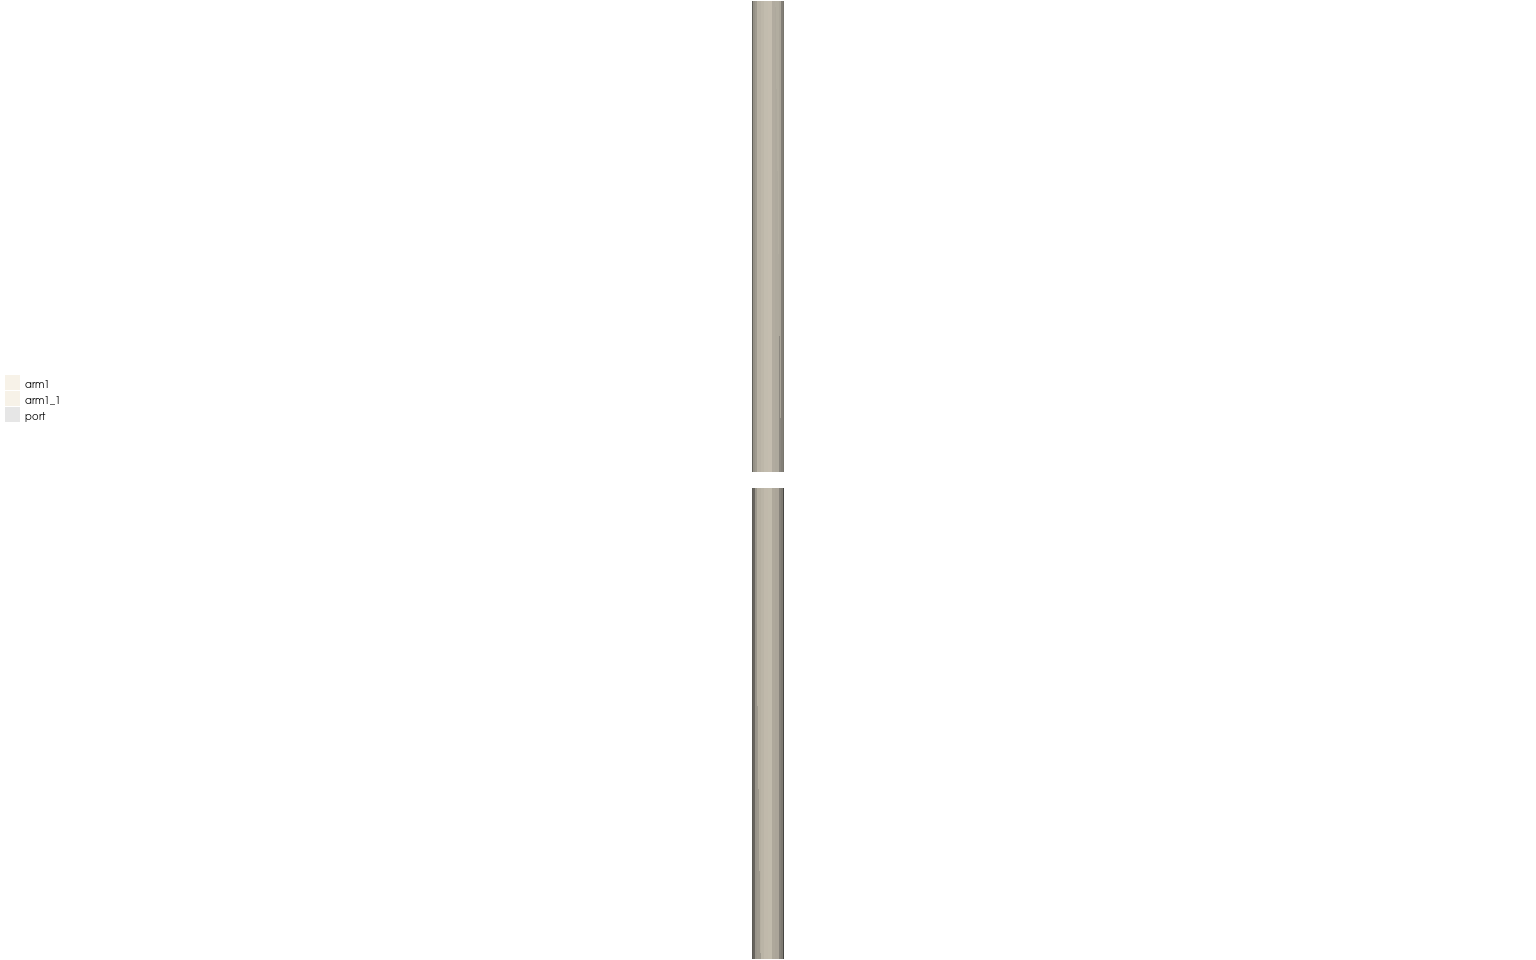

True

In [23]:
my_plot = hfss.plot(show=False, plot_air_objects=False)
my_plot.show_axes = False
my_plot.show_grid = False
my_plot.isometric_view = False
my_plot.plot(
    os.path.join(hfss.working_directory, "Image.jpg"),
)

#### Assign the boundary conditions


We create the open region at the design frequency

In [24]:
hfss.create_open_region(frequency=frequency_str)
hfss.modeler.fit_all()

PyAEDT INFO: Open Region correctly created.
PyAEDT INFO: Project Antenna_Lab_Q4T0AX Saved correctly


#### Create a lumped port

A lumped port is assigned as the excitation to the already created 2D sheet

In [25]:
hfss.lumped_port(assignment=port.name, integration_line=2, name="terminal_port")

PyAEDT INFO: Parsing design objects. This operation can take time
PyAEDT INFO: Parsing C:/Users/cgomezmo/OneDrive - ANSYS, Inc/Documents/Ansoft/Antenna_Lab_Q4T0AX.aedt.
PyAEDT INFO: File C:/Users/cgomezmo/OneDrive - ANSYS, Inc/Documents/Ansoft/Antenna_Lab_Q4T0AX.aedt correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: aedt file load time 0.08941435813903809
PyAEDT INFO: 3D Modeler objects parsed. Elapsed time: 0m 0sec
PyAEDT INFO: Boundary Lumped Port terminal_port has been correctly created.


#### Create the solution setup

We create a solution setup at the design frequency with a maximum number of passes equal to 10

In [26]:
setup = hfss.create_setup("MySetup")
setup.props["Frequency"] = frequency_str
setup.props["MaximumPasses"] = 10

and then we define the frequency sweep

In [27]:
sweep = hfss.create_linear_count_sweep(setup=setup.name, 
                               units="GHz",
                               start_frequency=start_frequency, 
                               stop_frequency=stop_frequency,
                               num_of_freq_points=101,
                               name="sweep1", 
                               save_fields=False, 
                               sweep_type="Interpolating")

PyAEDT INFO: Linear count sweep sweep1 has been correctly created.


#### Analyze

Finally, the project is saved and ready to analyze

In [28]:
hfss.save_project()

PyAEDT INFO: Project Antenna_Lab_Q4T0AX Saved correctly


True

In [29]:
hfss.analyze(cores=12)

PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/HFSS correctly changed.
PyAEDT INFO: Solving all design setups.
PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/HFSS correctly changed.
PyAEDT INFO: Design setup None solved correctly in 0.0h 0.0m 28.0s


True

### 3. Antenna post-processing

#### Scattering


We use *scikit-rf* library to get the touchstone data for postprocessing 

In [30]:
from matplotlib import pyplot as plt

In [31]:
touchstone_data = hfss.get_touchstone_data("MySetup")[0]

PyAEDT INFO: Solution Data Correctly Loaded.


Create a rectangular plot to visualize the S11 parameter


Text(0.5, 30.09999999999999, 'Frequency (GHz)')

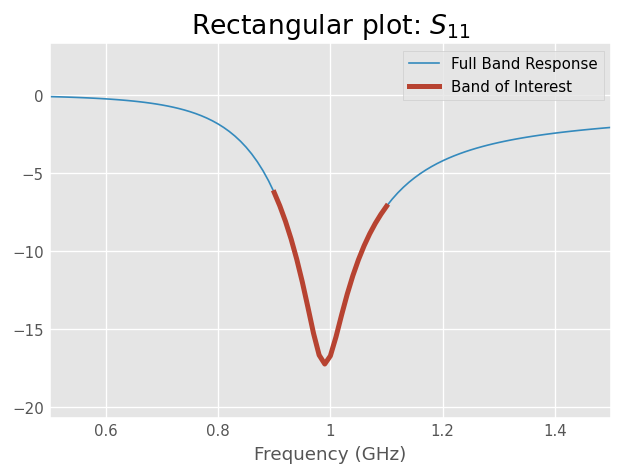

In [32]:
plt.title('Rectangular plot: $S_{11}$')

touchstone_data.s11.plot_s_db(label='Full Band Response')
touchstone_data.s11['0.9-1.1'].plot_s_db(lw=3,label='Band of Interest')
plt.xlabel('Frequency (GHz)')

Plot the input impedance in the Smith Chart

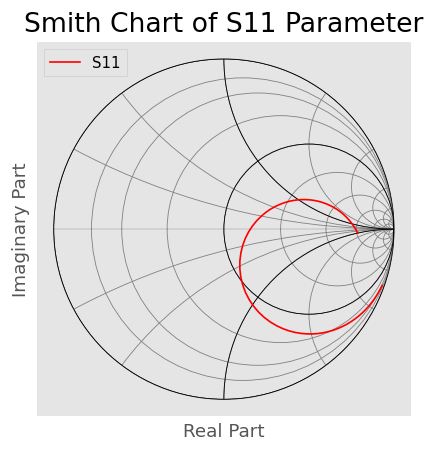

In [33]:
touchstone_data.plot_s_smith(m=0, n=0, color='red')
# Add titles and labels
plt.title('Smith Chart of S11 Parameter')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.legend()
plt.show()

In [34]:
import numpy as np

#### Get S11 parameter 

In the following lines, we are going to get the minimum of the S11 to see what is the exact operating frequency of the design antenna


In [35]:
s11 = touchstone_data.s[:, 0, 0]

In [36]:
s11_magnitude = np.abs(s11)


In [37]:
min_index = np.argmin(s11_magnitude)


In [38]:
resonance_frequency = touchstone_data.frequency.f[min_index] 


In [39]:
print(f"Resonance frequency: {resonance_frequency:.4f} GHz")

Resonance frequency: 0.9900 GHz


#### Exercise 1

Why the resonance frequency is different from 1GHZ?

#### Input Impedance at 1 GHz

Now, we are going to obtain the input impedance at our desired frequency, namely 1GHz. This will be the load impedance for our matching network

In [40]:
target_freq = 1
idx = (touchstone_data.frequency.f == target_freq).nonzero()[0][0]

In [41]:
z_params = touchstone_data.z
z_1ghz = z_params[idx, 0, 0]

real_part = z_1ghz.real
imaginary_part = z_1ghz.imag

In [42]:
imaginary_part

-2.355921233118356

In [43]:
real_part

66.88093761569358

#### 2D Farfield

We can also plot the radiation pattern in *Ansys HFSS* as follows

In [44]:
new_report = hfss.post.reports_by_category.far_field("dB(GainTotal)", hfss.nominal_adaptive, "3D")
new_report.primary_sweep = "Theta"
new_report.far_field_sphere = "3D"
new_report.secondary_sweep_range = [0]

In [45]:
new_report.create()

True

In [46]:
hfss.post.oreportsetup.AddMarker(new_report.plot_name, "m1", "dB(GainTotal) : MySetup : LastAdaptive : dipole_length=\'13.5cm\' dipole_radius=\'0.225cm\' feed_gap=\'0.225cm\' Freq=\'1GHz\' Phi=\'0deg\' : Cartesian", "90deg")

And get the result to plot here the 2D radiation pattern in a polar plot

In [47]:
solutions = new_report.get_solution_data()

PyAEDT INFO: Solution Data Correctly Loaded.


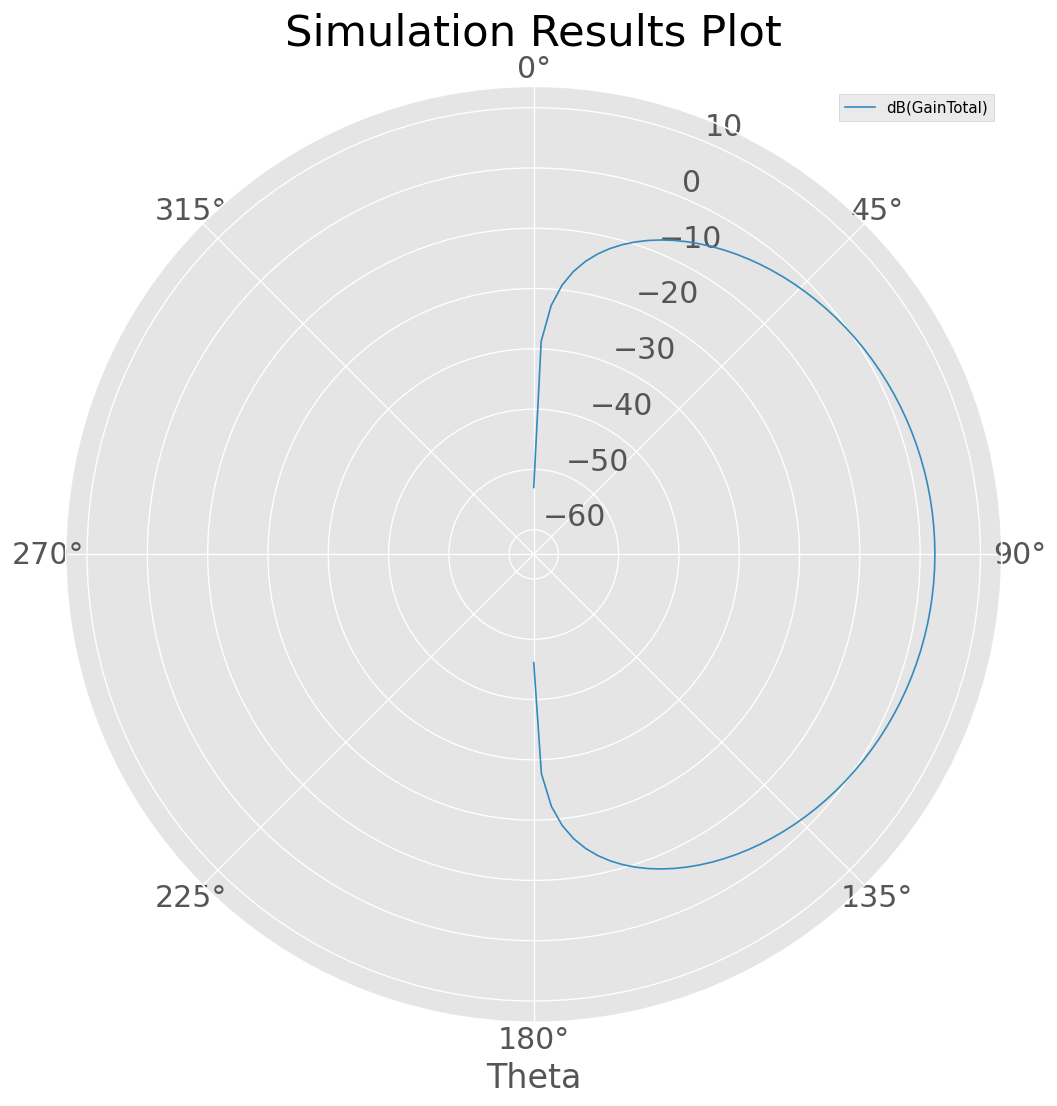

In [48]:
solutions.plot(is_polar=True)

#### Exercise 2 

What is the direction for the maximum radiation? Does it match with the expected angle?

#### 3D Farfield

Also, we can plot the 3D radiation pattern at 1GHz here using the following commands. You can modify  the scale and hide/show the dipole and/or radiation pattern. After that, close the *PyVista* windows to continue

In [49]:
ffdata = hfss.get_antenna_data()
ffdata.farfield_data.plot_3d(show=True, show_as_standalone=True)

PyAEDT INFO: Parsing C:/Users/cgomezmo/OneDrive - ANSYS, Inc/Documents/Ansoft/Antenna_Lab_Q4T0AX.aedt.
PyAEDT INFO: File C:/Users/cgomezmo/OneDrive - ANSYS, Inc/Documents/Ansoft/Antenna_Lab_Q4T0AX.aedt correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: aedt file load time 0.07772326469421387
PyAEDT INFO: No far field sphere is defined. Using 3D
PyAEDT INFO: Solution Data Correctly Loaded.
PyAEDT INFO: Exporting antenna metadata...
PyAEDT INFO: Antenna metadata exported.
PyAEDT INFO: Exporting geometry...
PyAEDT INFO: Exporting embedded element patterns.... Done: 0.4826693534851074 seconds


#### Release AEDT

After obtaining these results, we can save the project and release AEDT 

In [50]:
hfss.save_project()

PyAEDT INFO: Project Antenna_Lab_Q4T0AX Saved correctly


True

In [51]:
project_path = hfss.project_file

In [52]:
design_name = hfss.design_name

In [53]:
hfss.release_desktop()

PyAEDT INFO: Desktop has been released and closed.


True

### 4. Designing the impedance matching network


Once we have obtained the input impedance at 1GHz, we can design the matching network for this antenna (outside Ansys Electronics Desktop). 

- Impedance matching is important for the following reasons:

1. Maximizing the power transfer. Maximum power is delivered to the load when the generator and the load are matched to the line and power loss in the line minimized
2. Improving signal-to-noise ratio of the system
3. Reducing amplitude and phase errors
4. Reducing reflected power toward generator

- The simplest type of matching network is the “L” network, which uses two reactive elements to match an arbitrary load impedance. The reactive elements can be inductive or capacitive, depending on the load impedance.
   
![SegmentLocal](matching.png "matching")

In this case, the load $Z_L$ is the input impedance of the antenna at 1GHz (obtained in the previous section). 

#### Exercise 3

Calculate the values of the inductor in series and the shunt capacitor necessay to match the obtained input impedance

#### Design the matching network

We define the load and the transmision line with characteristic impedance equal to $Z_0$ 

In [54]:
import skrf as rf

In [55]:
Z_L = real_part + imaginary_part
Z_0 = 50
f_0_str = '1GHz'

#### Frequency band centered on the frequency of interest

In [56]:
frequency = rf.Frequency(start=0.9, stop=1.5, npoints=401, unit='GHz')

#### Transmission line Media

In [57]:
line = rf.DefinedGammaZ0(frequency=frequency, z0=Z_0)

#### Load Network

Now, we load the created transmision line with the input impedance of the antenna $Z_L$

In [58]:
load = line.load(rf.zl_2_Gamma0(Z_0, Z_L))

And define the matching network as an inductor in series and a shut capacitor

In [59]:
def matching_network_LC_1(L, C):
    ' L and C in nH and pF'
    return line.inductor(L*1e-9)**line.shunt_capacitor(C*1e-12)**load

Finding the set of inductance 
 and the capacitance 
 which matches the load is an optimization problem. The *scipy* package provides the necessary optimization function(s) for that

In [60]:
from scipy.optimize import minimize

In [61]:
# Initial guess values
L0 = 10 # nH
C0 = 1 # pF
x0 = (L0, C0)
# bounds
L_minmax = (1, 100) #nH
C_minmax = (0.1, 10) # pF

# The objective functions minimize the return loss at the target frequency f_0
def optim_fun_1(x, f0=f_0_str):
    _ntw = matching_network_LC_1(*x)
    return np.abs(_ntw[f_0_str].s).ravel()

In [62]:
res1 = minimize(optim_fun_1, x0, bounds=(L_minmax, C_minmax))
print(f'Optimum found for LC network 1: L={res1.x[0]} nH and C={res1.x[1]} pF')

Optimum found for LC network 1: L=4.286929618888124 nH and C=1.3287651428048362 pF


A new circuit with the solved matching network and the antenna is created

In [63]:
C = res1.x[1]

In [64]:
L = res1.x[0]

In [65]:
C

1.3287651428048362

In [66]:
L

4.286929618888124

#### Exercise 4

Are the computed values similar to the calculated one in Exercise 3?

### 5. Co-simulation in *Ansys Circuit*

We can verify this new circuit in Ansys Electronics Desktop by performing co-simulation. The method of co-simulation of electromagnetics and circuit takes advantage of high accuracy of electromagnetics and the speed of circuit analysis while designing any electrical component or system. In this case, we perform a co-simulation using the dipole antenna model with *Ansys HFSS* and *Ansys Circuit*. For that, we open the previous project using the following commands

In [67]:
import pyaedt
import os
hfss = pyaedt.Hfss(version="2024.2", student_version=False, project=project_path, design=design_name, new_desktop=True)

PyAEDT INFO: Parsing C:/Users/cgomezmo/OneDrive - ANSYS, Inc/Documents/Ansoft/Antenna_Lab_Q4T0AX.aedt.
PyAEDT INFO: Python version 3.10.12 (remotes/origin/3b5d0b535dfa1177dc4fc3b6f40c990a1085eaab-dirty:3b5d0b53, Mar 25 2) [MSC v.1920 64 bit (AMD64)]
PyAEDT INFO: PyAEDT version 0.10.0.
PyAEDT INFO: Initializing new Desktop session.
PyAEDT INFO: File C:/Users/cgomezmo/OneDrive - ANSYS, Inc/Documents/Ansoft/Antenna_Lab_Q4T0AX.aedt correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Log on console is enabled.
PyAEDT INFO: Log on file C:\Users\cgomezmo\AppData\Local\Temp\pyaedt_cgomezmo_a7045598-5de0-47ab-a154-4749e318452b.log is enabled.
PyAEDT INFO: Log on AEDT is enabled.
PyAEDT INFO: Debug logger is disabled. PyAEDT methods will not be logged.
PyAEDT INFO: Launching PyAEDT with gRPC plugin.
PyAEDT INFO: New AEDT session is starting on gRPC port 65234
PyAEDT INFO: AEDT installation Path C:\Program Files\AnsysEM\v242\Win64
PyAEDT INFO: Ansoft.ElectronicsDesktop.2024.2 version started wit

#### Insert Circuit design

After that, we insert a *Circuit* design in the same project as our previously created *HFSS* antenna design

In [68]:
circuit = pyaedt.Circuit(design="Matching Network",version="2024.2")

PyAEDT INFO: Python version 3.10.12 (remotes/origin/3b5d0b535dfa1177dc4fc3b6f40c990a1085eaab-dirty:3b5d0b53, Mar 25 2) [MSC v.1920 64 bit (AMD64)]
PyAEDT INFO: PyAEDT version 0.10.0.
PyAEDT INFO: Returning found Desktop session with PID 22772!
PyAEDT INFO: No project is defined. Project Antenna_Lab_Q4T0AX exists and has been read.
PyAEDT INFO: Added design 'Matching Network' of type Circuit Design.
PyAEDT INFO: Aedt Objects correctly read


In [69]:
circuit.modeler.schematic_units = "mil"

PyAEDT INFO: ModelerCircuit class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: ModelerNexxim class has been initialized!
PyAEDT INFO: Modeler class has been initialized! Elapsed time: 0m 0sec


#### Convert units

In [70]:
L_nH = str(L) + "nH"

In [71]:
C_pF = str(C) + "pF"

#### Add *HFSS* component

And we add our *HFSS* antenna as a component in the *Circuit* schematic

In [72]:
hfss_comp = circuit.modeler.schematic.add_subcircuit_dynamic_link(hfss, name=design_name)


In [73]:
circuit.modeler.zoom_to_fit()

In [74]:
x_hfss, y_hfss = hfss_comp.pins[0].location

After the antenna, we place the inductor with the computed optimum value

In [75]:
inductor = circuit.modeler.schematic.create_inductor("L_match", L_nH, [x_hfss-250, y_hfss])

In [76]:
inductor.pins[1].connect_to_component(assignment=hfss_comp.pins[0], use_wire=True)

True

In [77]:
circuit.modeler.zoom_to_fit()

Then, we place the capacitor

In [78]:
capacitor = circuit.modeler.schematic.create_capacitor("C_match", C_pF, [x_hfss-250, y_hfss-250])

In [79]:
capacitor.pins[1].connect_to_component(assignment=hfss_comp.pins[0], use_wire=True)

True

In [80]:
circuit.modeler.zoom_to_fit()

In [81]:
c_x, c_y = capacitor.pins[0].location

In [82]:
gnd = circuit.modeler.components.create_gnd(location=[c_x, c_y-100])

And finally, we add the port

In [83]:
port = circuit.modeler.components.add_pin_iports(name="myport", id_num=inductor.id)

In [84]:
circuit.modeler.zoom_to_fit()

#### Create Setup and analyze

The solution setup is created

In [85]:
setup1 = circuit.create_setup("MyLNA")
setup1.props["SweepDefinition"]["Data"] = f"LINC {start_frequency}GHz {stop_frequency}GHz 251"

In [86]:
circuit.analyze_setup("MyLNA")

PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/Circuit Design correctly changed.
PyAEDT INFO: Solving design setup MyLNA
PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/Circuit Design correctly changed.
PyAEDT INFO: Design setup MyLNA solved correctly in 0.0h 0.0m 3.0s


True

#### Scattering post processing

We now get the results

In [87]:
solutions = circuit.post.get_solution_data(expressions=circuit.get_traces_for_plot(category="S"))

PyAEDT INFO: Post class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Solution Data Correctly Loaded.


In [88]:
data = solutions.data_db20()

In [89]:
freq = solutions.primary_sweep_values

#### Comparison

Then, we get the original data

In [90]:
original_data = touchstone_data.s11.s_db.flatten().tolist()

In [91]:
original_freq =  [x for x in touchstone_data.s11.f.tolist()] 

And we plot the S11 comparision between the antenna and the antenna with the matching network

In [92]:
plt.close('all')

Create the plot

In [93]:
plt.figure(figsize=(10, 6))

<Figure size 1200x720 with 0 Axes>

Plot the first set of data

In [94]:
plt.plot(original_freq, original_data, label='Original', marker='o', linestyle='-', color='blue')

Plot the second set of data

In [95]:
plt.plot(freq, data, label='Matched', marker='s', linestyle='--', color='red')

Add title and labels

In [96]:
plt.title('Antenna S11')
plt.xlabel('Frequency')
plt.ylabel('S parameter')

Text(0, 0.5, 'S parameter')

In [97]:
plt.legend()
plt.grid(True)

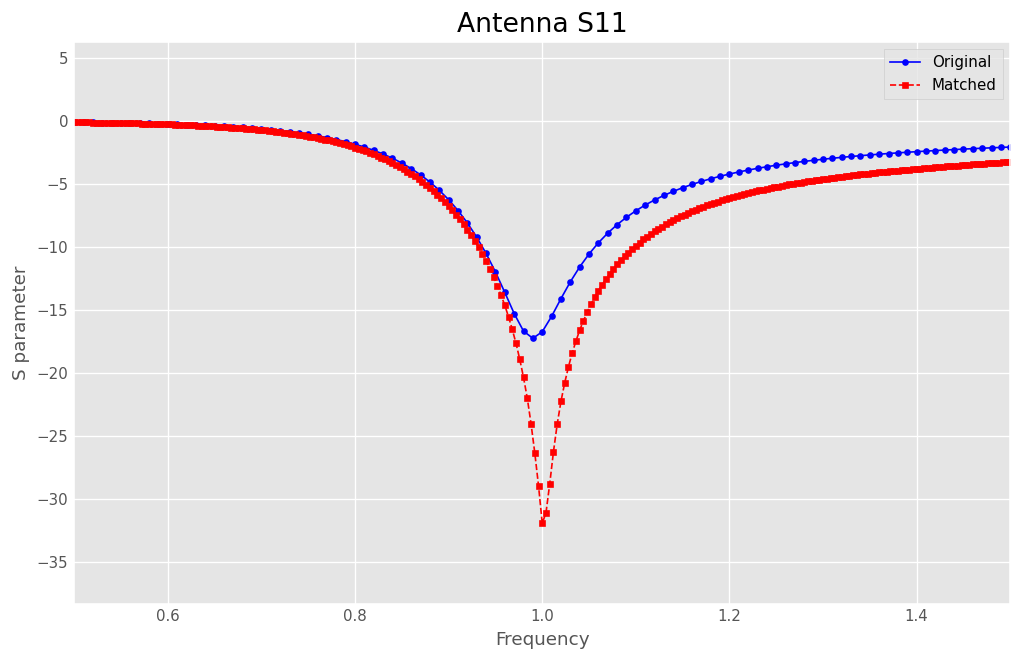

In [98]:
plt.show()

#### Exercise 5

Does the antenna performance improve thanks to the matching? What are the observable differences in frequency and matching level between both results?

#### Save and close

In [99]:
hfss.save_project()

PyAEDT INFO: Project Antenna_Lab_Q4T0AX Saved correctly


True

In [100]:
hfss.release_desktop()

PyAEDT INFO: Desktop has been released and closed.


True

### 6. Final exercise: Parametric analysis

In this extended part, write the code to study how the length of the dipole affects its frequency perfomance. For that, you can add a parameteric sweep of the created variable *dipole_length* between 12cm and 14cm using 6 steps and plot the S11 parameter. 

In [101]:
# Enter your code here for opening the created project and design as it was done in Section 5 
# adding a parametric sweep (hint: 'hfss.parametrics.add') and analyze
# and plot the S11 parameter (hint: 'hfss.create_scattering' and play with 'variations')
# Check the functions info in: https://aedt.docs.pyansys.com/version/stable/index.html

#### Question

How the length of the dipole affects the operating frequency of the antenna?

### 7. Solution: Parametric analysis

#### Open the previous project

In [102]:
import pyaedt
import os
hfss = pyaedt.Hfss(version="2024.2", student_version=False, project=project_path, design=design_name, new_desktop=True)

PyAEDT INFO: Parsing C:/Users/cgomezmo/OneDrive - ANSYS, Inc/Documents/Ansoft/Antenna_Lab_Q4T0AX.aedt.
PyAEDT INFO: Python version 3.10.12 (remotes/origin/3b5d0b535dfa1177dc4fc3b6f40c990a1085eaab-dirty:3b5d0b53, Mar 25 2) [MSC v.1920 64 bit (AMD64)]
PyAEDT INFO: PyAEDT version 0.10.0.
PyAEDT INFO: Initializing new Desktop session.
PyAEDT INFO: Log on console is enabled.
PyAEDT INFO: Log on file C:\Users\cgomezmo\AppData\Local\Temp\pyaedt_cgomezmo_a7045598-5de0-47ab-a154-4749e318452b.log is enabled.
PyAEDT INFO: Log on AEDT is enabled.
PyAEDT INFO: File C:/Users/cgomezmo/OneDrive - ANSYS, Inc/Documents/Ansoft/Antenna_Lab_Q4T0AX.aedt correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Debug logger is disabled. PyAEDT methods will not be logged.
PyAEDT INFO: Launching PyAEDT with gRPC plugin.
PyAEDT INFO: New AEDT session is starting on gRPC port 65318
PyAEDT INFO: AEDT installation Path C:\Program Files\AnsysEM\v242\Win64
PyAEDT INFO: Ansoft.ElectronicsDesktop.2024.2 version started wit

#### Add parametric analysis and analyze

In [103]:
sweep = hfss.parametrics.add("dipole_length", 12, 14, 3)


In [104]:
hfss.ooptimetrics.SolveSetup(sweep.name)

#### Plot the results

In [105]:
st={'dipole_length': 'All',
 'feed_gap': '0.225cm',
 'dipole_radius': '0.225cm',
 'Freq': 'All'}

In [106]:
nw=hfss.create_scattering(plot="S11 parameter - parametric sweep (dB)", variations= st)

PyAEDT INFO: Modeler class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: PostProcessor class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Post class has been initialized! Elapsed time: 0m 0sec


#### Save and close

In [107]:
hfss.save_project()


PyAEDT INFO: Project Antenna_Lab_Q4T0AX Saved correctly


True

In [108]:
hfss.release_desktop()

PyAEDT INFO: Desktop has been released and closed.


True